# 1.6 — The distribution, as code 🚀 Builder

Reproducimos el explorable de distribuciones de grado con el snapshot de la semana 1, implementamos el binning de los *Goodies* y comparamos contra distribuciones sintéticas (exponencial y power law).

## Parte 1 — Cargar como dirigido, sin perder aislados, y verificar

In [1]:
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
import sgi
sgi.set_style()

G, nodes = sgi.load_marvel(week=1)
U = G.to_undirected()
n, m, mu = G.number_of_nodes(), G.number_of_edges(), U.number_of_edges()
print(f"n = {n}   m dirigido = {m}   m no dirigido = {mu}   <k> = {2*mu/n:.2f}")
print(f"aislados: {sum(1 for v in G if G.degree(v) == 0)}")
assert n == 303 and m == 1784 and mu == 1434
# ¿por qué 1784 -> 1434? cada par mutuo A<->B son 2 aristas dirigidas pero 1 no dirigida
mutuos = sum(1 for a, b in G.edges if G.has_edge(b, a)) // 2
print(f"pares mutuos: {mutuos}  →  {m} - {mutuos} = {m - mutuos} = m no dirigido ✓")
assert m - mutuos == mu

n = 303   m dirigido = 1784   m no dirigido = 1434   <k> = 9.47
aislados: 17
pares mutuos: 350  →  1784 - 350 = 1434 = m no dirigido ✓


## Parte 2 — In- y out-degree en lineal y log–log, contra *k+1*

In [2]:
table = sgi.degree_table(G, nodes)
print("top-5 in-degree");  display(sgi.top(table, "in"))
print("top-5 out-degree"); display(sgi.top(table, "out"))

top-5 in-degree


,name,node_id,in_degree
0,Spider-Man,Spider-Man,106
1,Hulk,Hulk,64
2,Wolverine (character),Wolverine_(character),60
3,Doctor Strange,Doctor_Strange,50
4,Deadpool,Deadpool,33


top-5 out-degree


,name,node_id,out_degree
0,Betsy Braddock,Betsy_Braddock,28
1,Cloak and Dagger (characters),Cloak_and_Dagger_(characters),24
2,Adam Warlock,Adam_Warlock,22
3,Venom (character),Venom_(character),21
4,She-Hulk,She-Hulk,20


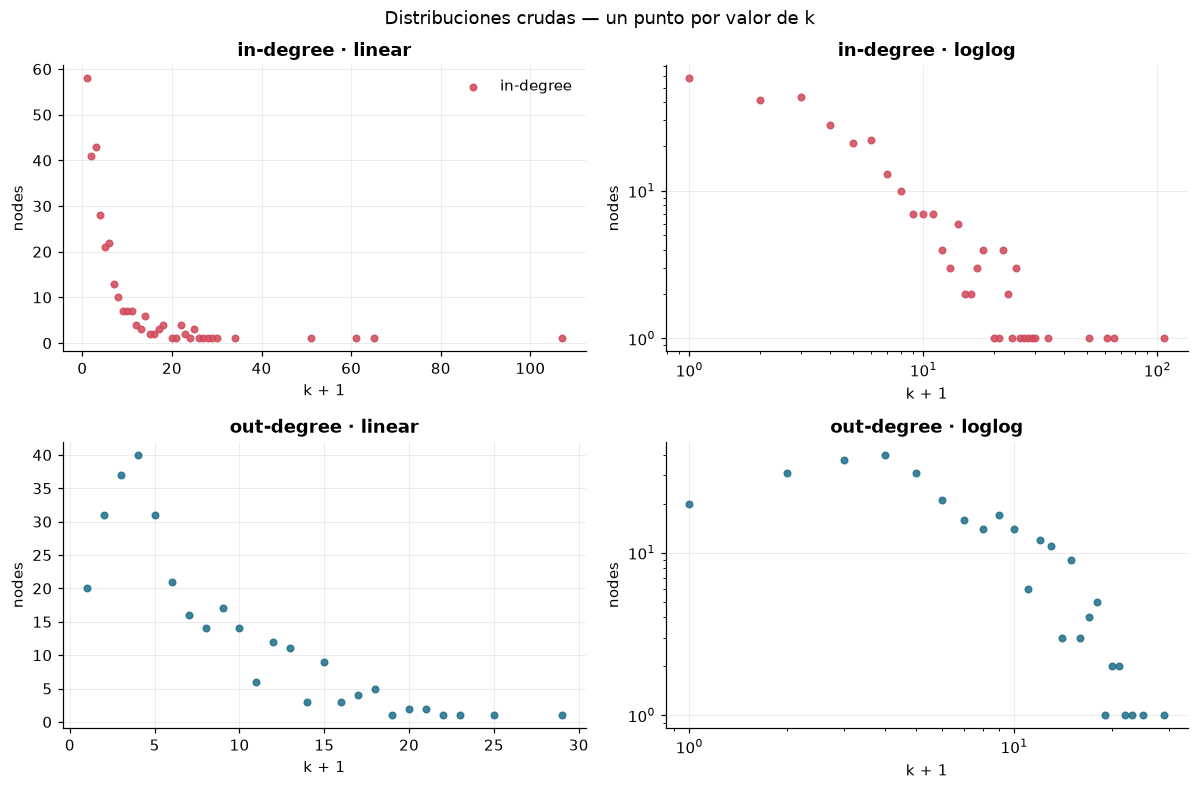

In [3]:
fig = sgi.degree_panels(table, binned=False)
fig.suptitle("Distribuciones crudas — un punto por valor de k", y=1.02); plt.show()

_Compara los top-5 con el leaderboard del explorable del curso y anota aquí si coinciden._

## Parte 3 — El binning de los Goodies

Bins de ancho 1 para *u = k+1* de 1 a 7, luego bins que doblan [8,16), [16,32), … Cada conteo se divide por el ancho del bin y se dibuja en la media geométrica de los enteros que cubre. **Donde el ancho es 1 debe coincidir exacto con los puntos crudos.**

,lo,hi,width,x,count,density,p
0,1,2,1,1.000000,58,58.00000,0.191419
1,2,3,1,2.000000,41,41.00000,0.135314
2,3,4,1,3.000000,43,43.00000,0.141914
3,4,5,1,4.000000,28,28.00000,0.092409
4,5,6,1,5.000000,21,21.00000,0.069307
5,6,7,1,6.000000,22,22.00000,0.072607
6,7,8,1,7.000000,13,13.00000,0.042904
7,8,16,8,11.265712,46,5.75000,0.018977
8,16,32,16,23.036030,26,1.62500,0.005363
9,32,64,32,46.579436,3,0.09375,0.000309


✓ coincide donde width=1  ·  ✓ los bins suman 303 nodos


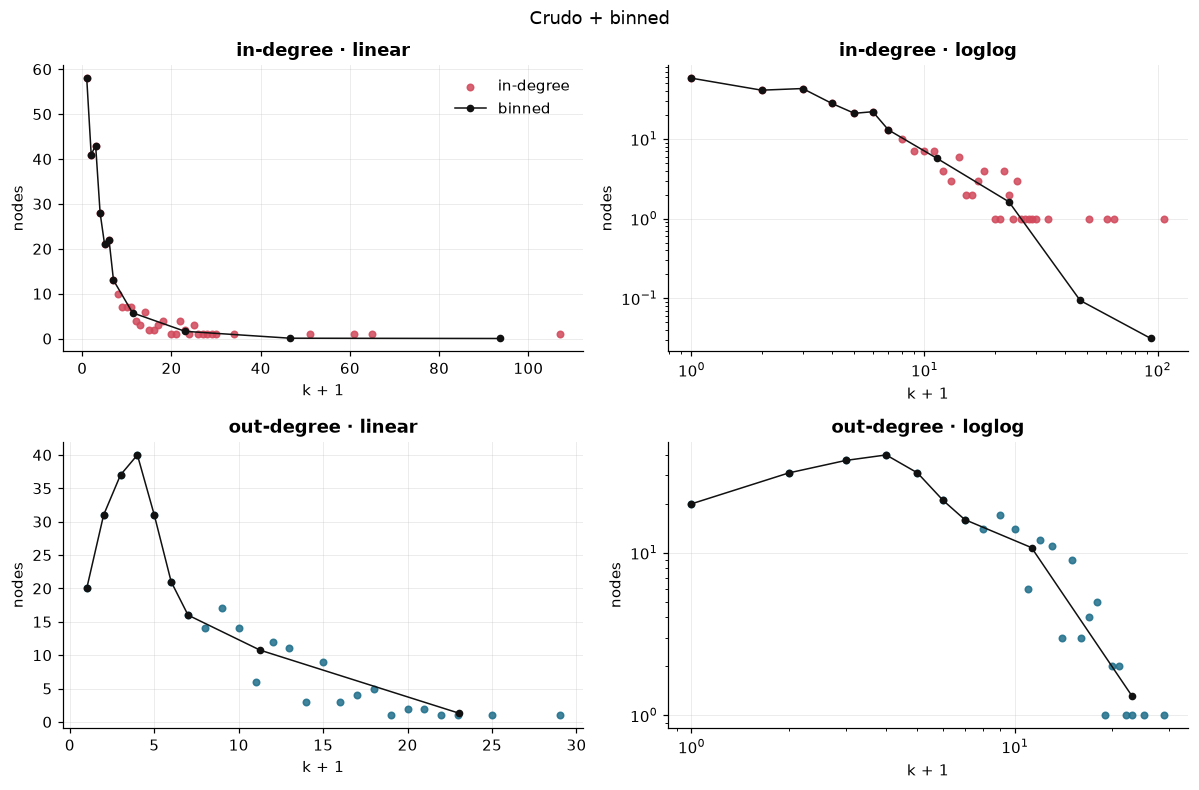

In [4]:
kin = table.in_degree.to_numpy()
raw, binned = sgi.raw_distribution(kin), sgi.goodies_bins(kin)
display(binned)

# la prueba que importa: coincidencia exacta donde width == 1
w1 = binned[binned.width == 1].set_index("lo")["density"]
r1 = raw.set_index("u")["count"].reindex(w1.index).fillna(0)
assert np.allclose(w1.values, r1.values), "binned != raw en los bins de ancho 1"
assert binned["count"].sum() == n
print("✓ coincide donde width=1  ·  ✓ los bins suman", n, "nodos")

fig = sgi.degree_panels(table, binned=True)
fig.suptitle("Crudo + binned", y=1.02); plt.show()

### ¿Qué pasa si *no* divides por el ancho?

El error clásico que fabrica una power law que no existe.

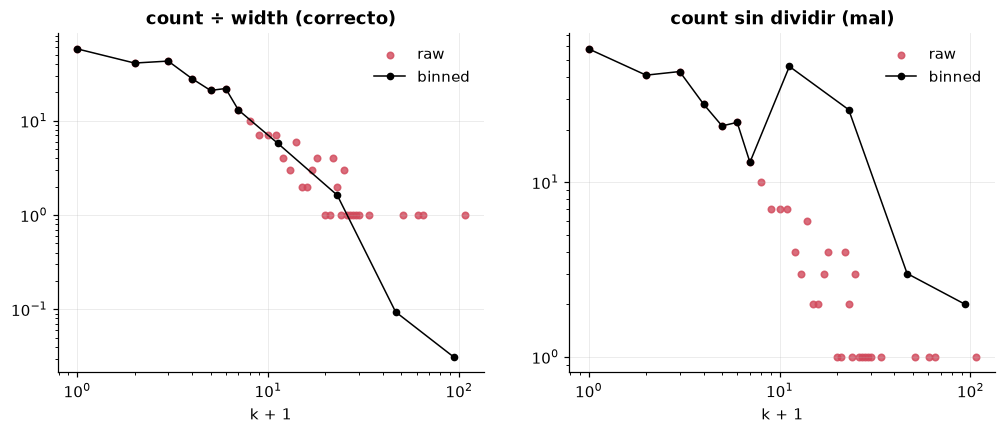

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, ycol, titulo in [(axes[0], "density", "count ÷ width (correcto)"), (axes[1], "count", "count sin dividir (mal)")]:
    b = binned[binned["count"] > 0]
    ax.scatter(raw.u, raw["count"], s=18, color=sgi.PALETTE["in"], alpha=.8, label="raw")
    ax.plot(b.x, b[ycol], "o-", color="k", ms=4, lw=1, label="binned")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_title(titulo); ax.set_xlabel("k + 1"); ax.legend(frameon=False)
plt.show()

## Parte 4 — Exponencial vs power law, en los cuatro pares de ejes

10,000 muestras de cada una, enteras, y la in-degree real encima. La pregunta: ¿en qué ejes se distinguen, y a cuál se parece la real?

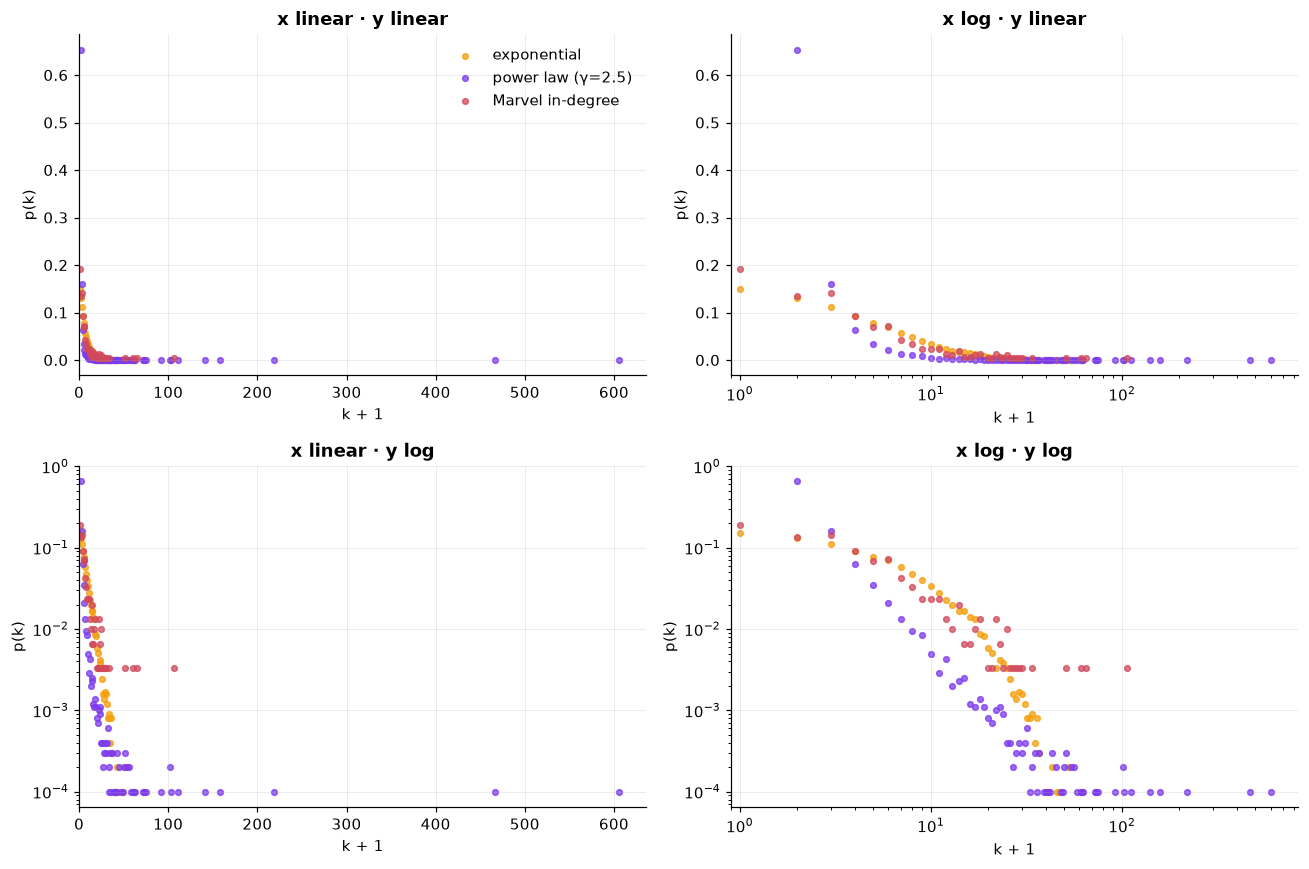

In [6]:
rng = np.random.default_rng(2026)
N = 10_000
media = kin.mean()

exp_k = np.floor(rng.exponential(scale=media, size=N)).astype(int)         # exponencial discreta, misma media
gamma, kmin = 2.5, 1
pl_k = np.floor(kmin * (1 - rng.random(N)) ** (-1 / (gamma - 1))).astype(int)  # power law discreta, p(k) ~ k^-2.5

specimens = {"exponential": (exp_k, "#f59e0b"), "power law (γ=2.5)": (pl_k, "#7c3aed"), "Marvel in-degree": (kin, sgi.PALETTE["in"])}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (xs, ys) in zip(axes.flat, [("linear", "linear"), ("log", "linear"), ("linear", "log"), ("log", "log")]):
    for nombre, (k, color) in specimens.items():
        d = sgi.raw_distribution(k)
        ax.scatter(d.u, d.p, s=14, alpha=.75, color=color, label=nombre)
    ax.set_xscale(xs); ax.set_yscale(ys)
    ax.set_title(f"x {xs} · y {ys}"); ax.set_xlabel("k + 1"); ax.set_ylabel("p(k)")
    ax.set_xlim(left=0.9 if xs == "log" else 0)
axes[0, 0].legend(frameon=False)
plt.tight_layout(); plt.show()

**Lectura (escribir a mano):**

_TODO — ¿en cuál de los cuatro paneles la exponencial se ve como recta? ¿y la power law? ¿A cuál se parece más la in-degree real, y en qué rango de k deja de parecerse?_